## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import pynance as pn
import talib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

## Load and Prepare Data

In [3]:
df = pd.read_csv('../data/raw/AAPL.csv')
print(f"   Shape: {df.shape} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

   Shape: (3774, 6) rows × 6 columns

Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


### HANDLE MISSING VALUES

In [4]:
print("MISSING VALUES")
missing = df.isnull().sum()
print(missing)

MISSING VALUES
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


- No missing values found

### DATA QUALITY CHECKS

In [5]:
print("DATA QUALITY CHECKS")

duplicates = df.duplicated(subset=['Date']).sum()
if duplicates > 0:
    df = df.drop_duplicates(subset=['Date'], keep='last')
    print(f"✅ Removed {duplicates} duplicate dates")
else:
    print("✅ No duplicate dates")

# Check impossible logic
violations = (df['High'] < df['Low']).sum()
if violations > 0:
    print(f"⚠️ {violations} rows where high < low")
else:
    print("✅ high >= low for all rows")

# Check for zero volume
zero_vol = (df['Volume'] == 0).sum()
if zero_vol > 0:
    print(f"⚠️ {zero_vol} rows with zero volume")
else:
    print("✅ All rows have positive volume")

DATA QUALITY CHECKS
✅ No duplicate dates
✅ high >= low for all rows
✅ All rows have positive volume


### Ensure Date is datetime

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

### Ensure numeric columns are float

In [7]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### Sort by date

In [8]:
df = df.sort_values('Date').reset_index(drop=True)

print(f"✅ Loaded data: {len(df)} rows")
print(f"   Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"   Close price range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")

✅ Loaded data: 3774 rows
   Date range: 2009-01-02 to 2023-12-29
   Close price range: $2.35 - $196.26


## Technical Indicators with TA-Lib

### MOVING AVERAGES (SMA and EMA)

In [9]:
print("MOVING AVERAGES")

# Define windows for moving averages
windows = [5, 10, 20, 50, 200]

# Calculate Simple Moving Averages (SMA)
for window in windows:
    df[f'SMA_{window}'] = talib.SMA(df['Close'], timeperiod=window)
    print(f"✅ SMA_{window} calculated")

# Calculate Exponential Moving Averages (EMA)
for window in windows:
    df[f'EMA_{window}'] = talib.EMA(df['Close'], timeperiod=window)
    print(f"✅ EMA_{window} calculated")

# Current SMA values (most recent)
print(f"\n📊 Current Moving Averages (as of {df['Date'].iloc[-1].date()}):")
print("-" * 50)
print(f"   Close Price: ${df['Close'].iloc[-1]:.2f}")
for window in windows:
    sma_val = df[f'SMA_{window}'].iloc[-1]
    ema_val = df[f'EMA_{window}'].iloc[-1]
    print(f"   SMA_{window}: ${sma_val:.2f}  |  EMA_{window}: ${ema_val:.2f}")

# Price vs Moving Average signals
print(f"\n📊 Price vs MA Signals:")
for window in windows:
    current_price = df['Close'].iloc[-1]
    sma = df[f'SMA_{window}'].iloc[-1]
    ema = df[f'EMA_{window}'].iloc[-1]
    
    if current_price > sma:
        print(f"   Price ABOVE SMA_{window} → Bullish signal")
    else:
        print(f"   Price BELOW SMA_{window} → Bearish signal")

MOVING AVERAGES
✅ SMA_5 calculated
✅ SMA_10 calculated
✅ SMA_20 calculated
✅ SMA_50 calculated
✅ SMA_200 calculated
✅ EMA_5 calculated
✅ EMA_10 calculated
✅ EMA_20 calculated
✅ EMA_50 calculated
✅ EMA_200 calculated

📊 Current Moving Averages (as of 2023-12-29):
--------------------------------------------------
   Close Price: $190.73
   SMA_5: $191.37  |  EMA_5: $191.57
   SMA_10: $192.76  |  EMA_10: $192.09
   SMA_20: $192.49  |  EMA_20: $191.43
   SMA_50: $184.81  |  EMA_50: $187.11
   SMA_200: $177.45  |  EMA_200: $176.11

📊 Price vs MA Signals:
   Price BELOW SMA_5 → Bearish signal
   Price BELOW SMA_10 → Bearish signal
   Price BELOW SMA_20 → Bearish signal
   Price ABOVE SMA_50 → Bullish signal
   Price ABOVE SMA_200 → Bullish signal


### RELATIVE STRENGTH INDEX (RSI)

In [10]:
print("RELATIVE STRENGTH INDEX (RSI)")

# Calculate RSI with standard 14-day period
rsi_period = 14
df['RSI'] = talib.RSI(df['Close'], timeperiod=rsi_period)

print(f"✅ RSI_{rsi_period} calculated")

# RSI interpretation
current_rsi = df['RSI'].iloc[-1]
print(f"\n📊 Current RSI: {current_rsi:.2f}")

# Overbought/Oversold conditions
overbought = 70
oversold = 30

if current_rsi > overbought:
    print(f"   ⚠️ OVERBOUGHT (RSI > {overbought}) → Potential sell signal / pullback coming")
elif current_rsi < oversold:
    print(f"   ⚠️ OVERSOLD (RSI < {oversold}) → Potential buy signal / bounce coming")
else:
    print(f"   ✅ NEUTRAL (RSI between {oversold} and {overbought})")

# Count overbought/oversold days in dataset
overbought_days = (df['RSI'] > overbought).sum()
oversold_days = (df['RSI'] < oversold).sum()
neutral_days = len(df) - overbought_days - oversold_days

print(f"\n📊 Historical RSI Distribution:")
print(f"   Overbought days (RSI > {overbought}): {overbought_days} ({overbought_days/len(df)*100:.1f}%)")
print(f"   Oversold days (RSI < {oversold}): {oversold_days} ({oversold_days/len(df)*100:.1f}%)")
print(f"   Neutral days: {neutral_days} ({neutral_days/len(df)*100:.1f}%)")

RELATIVE STRENGTH INDEX (RSI)
✅ RSI_14 calculated

📊 Current RSI: 51.12
   ✅ NEUTRAL (RSI between 30 and 70)

📊 Historical RSI Distribution:
   Overbought days (RSI > 70): 574 (15.2%)
   Oversold days (RSI < 30): 68 (1.8%)
   Neutral days: 3132 (83.0%)


### MACD (Moving Average Convergence Divergence)

In [11]:
print("MACD (MOVING AVERAGE CONVERGENCE DIVERGENCE)")

# Calculate MACD with standard parameters
# fast=12, slow=26, signal=9
df['MACD'], df['MACD_signal'], df['MACD_histogram'] = talib.MACD(
    df['Close'], 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)

print("✅ MACD calculated (fast=12, slow=26, signal=9)")
print("   - MACD line: 12-period EMA minus 26-period EMA")
print("   - Signal line: 9-period EMA of MACD line")
print("   - Histogram: MACD line minus Signal line")

# Current MACD values
current_macd = df['MACD'].iloc[-1]
current_signal = df['MACD_signal'].iloc[-1]
current_hist = df['MACD_histogram'].iloc[-1]

print(f"\n📊 Current MACD Values (as of {df['Date'].iloc[-1].date()}):")
print("-" * 50)
print(f"   MACD Line: {current_macd:.4f}")
print(f"   Signal Line: {current_signal:.4f}")
print(f"   Histogram: {current_hist:.4f}")

# MACD signals
print(f"\n📊 MACD Signals:")

# Crossover signals
if current_macd > current_signal:
    print(f"   ✅ MACD ABOVE Signal line → Bullish momentum")
else:
    print(f"   ⚠️ MACd BELOW Signal line → Bearish momentum")

# Histogram direction
if current_hist > 0:
    print(f"   ✅ Positive histogram → Bullish momentum increasing")
else:
    print(f"   ⚠️ Negative histogram → Bearish momentum increasing")

# Detect recent crossovers (last 3 days)
if len(df) > 3:
    prev_macd = df['MACD'].iloc[-2]
    prev_signal = df['MACD_signal'].iloc[-2]
    
    # Bullish crossover (MACD crosses above Signal)
    if prev_macd <= prev_signal and current_macd > current_signal:
        print(f"   🔥 BULLISH CROSSOVER detected! (MACD crossed above Signal line)")
    
    # Bearish crossover (MACD crosses below Signal)
    if prev_macd >= prev_signal and current_macd < current_signal:
        print(f"   ⚠️ BEARISH CROSSOVER detected! (MACD crossed below Signal line)")

MACD (MOVING AVERAGE CONVERGENCE DIVERGENCE)
✅ MACD calculated (fast=12, slow=26, signal=9)
   - MACD line: 12-period EMA minus 26-period EMA
   - Signal line: 9-period EMA of MACD line
   - Histogram: MACD line minus Signal line

📊 Current MACD Values (as of 2023-12-29):
--------------------------------------------------
   MACD Line: 1.5595
   Signal Line: 2.4246
   Histogram: -0.8651

📊 MACD Signals:
   ⚠️ MACd BELOW Signal line → Bearish momentum
   ⚠️ Negative histogram → Bearish momentum increasing


### COMBINED SIGNALS TABLE

In [12]:
print("COMBINED TECHNICAL SIGNALS SUMMARY")

# Create a summary of current signals
signals = {
    'Indicator': ['Price', 'SMA_20', 'SMA_50', 'RSI', 'MACD', 'MACD_Histogram'],
    'Value': [
        f"${df['Close'].iloc[-1]:.2f}",
        f"${df['SMA_20'].iloc[-1]:.2f}",
        f"${df['SMA_50'].iloc[-1]:.2f}",
        f"{df['RSI'].iloc[-1]:.1f}",
        f"{df['MACD'].iloc[-1]:.4f}",
        f"{df['MACD_histogram'].iloc[-1]:.4f}"
    ],
    'Signal': [
        'Reference',
        'Bullish' if df['Close'].iloc[-1] > df['SMA_20'].iloc[-1] else 'Bearish',
        'Bullish' if df['Close'].iloc[-1] > df['SMA_50'].iloc[-1] else 'Bearish',
        'Overbought' if df['RSI'].iloc[-1] > 70 else ('Oversold' if df['RSI'].iloc[-1] < 30 else 'Neutral'),
        'Bullish' if df['MACD'].iloc[-1] > df['MACD_signal'].iloc[-1] else 'Bearish',
        'Bullish' if df['MACD_histogram'].iloc[-1] > 0 else 'Bearish'
    ]
}

signals_df = pd.DataFrame(signals)
print("\n", signals_df.to_string(index=False))

# Overall sentiment
bullish_signals = sum(1 for s in signals_df['Signal'][1:] if s == 'Bullish')
bearish_signals = sum(1 for s in signals_df['Signal'][1:] if s == 'Bearish')
neutral_signals = sum(1 for s in signals_df['Signal'][1:] if s == 'Neutral')

print(f"\n📊 Overall Technical Score:")
print(f"   Bullish signals: {bullish_signals}")
print(f"   Bearish signals: {bullish_signals}")
print(f"   Neutral signals: {neutral_signals}")

if bullish_signals > bearish_signals:
    print(f"   ✅ OVERALL: BULLISH BIAS")
elif bearish_signals > bullish_signals:
    print(f"   ⚠️ OVERALL: BEARISH BIAS")
else:
    print(f"   ➡️ OVERALL: NEUTRAL / MIXED SIGNALS")

COMBINED TECHNICAL SIGNALS SUMMARY

      Indicator   Value    Signal
         Price $190.73 Reference
        SMA_20 $192.49   Bearish
        SMA_50 $184.81   Bullish
           RSI    51.1   Neutral
          MACD  1.5595   Bearish
MACD_Histogram -0.8651   Bearish

📊 Overall Technical Score:
   Bullish signals: 1
   Bearish signals: 1
   Neutral signals: 1
   ⚠️ OVERALL: BEARISH BIAS


### Visualization

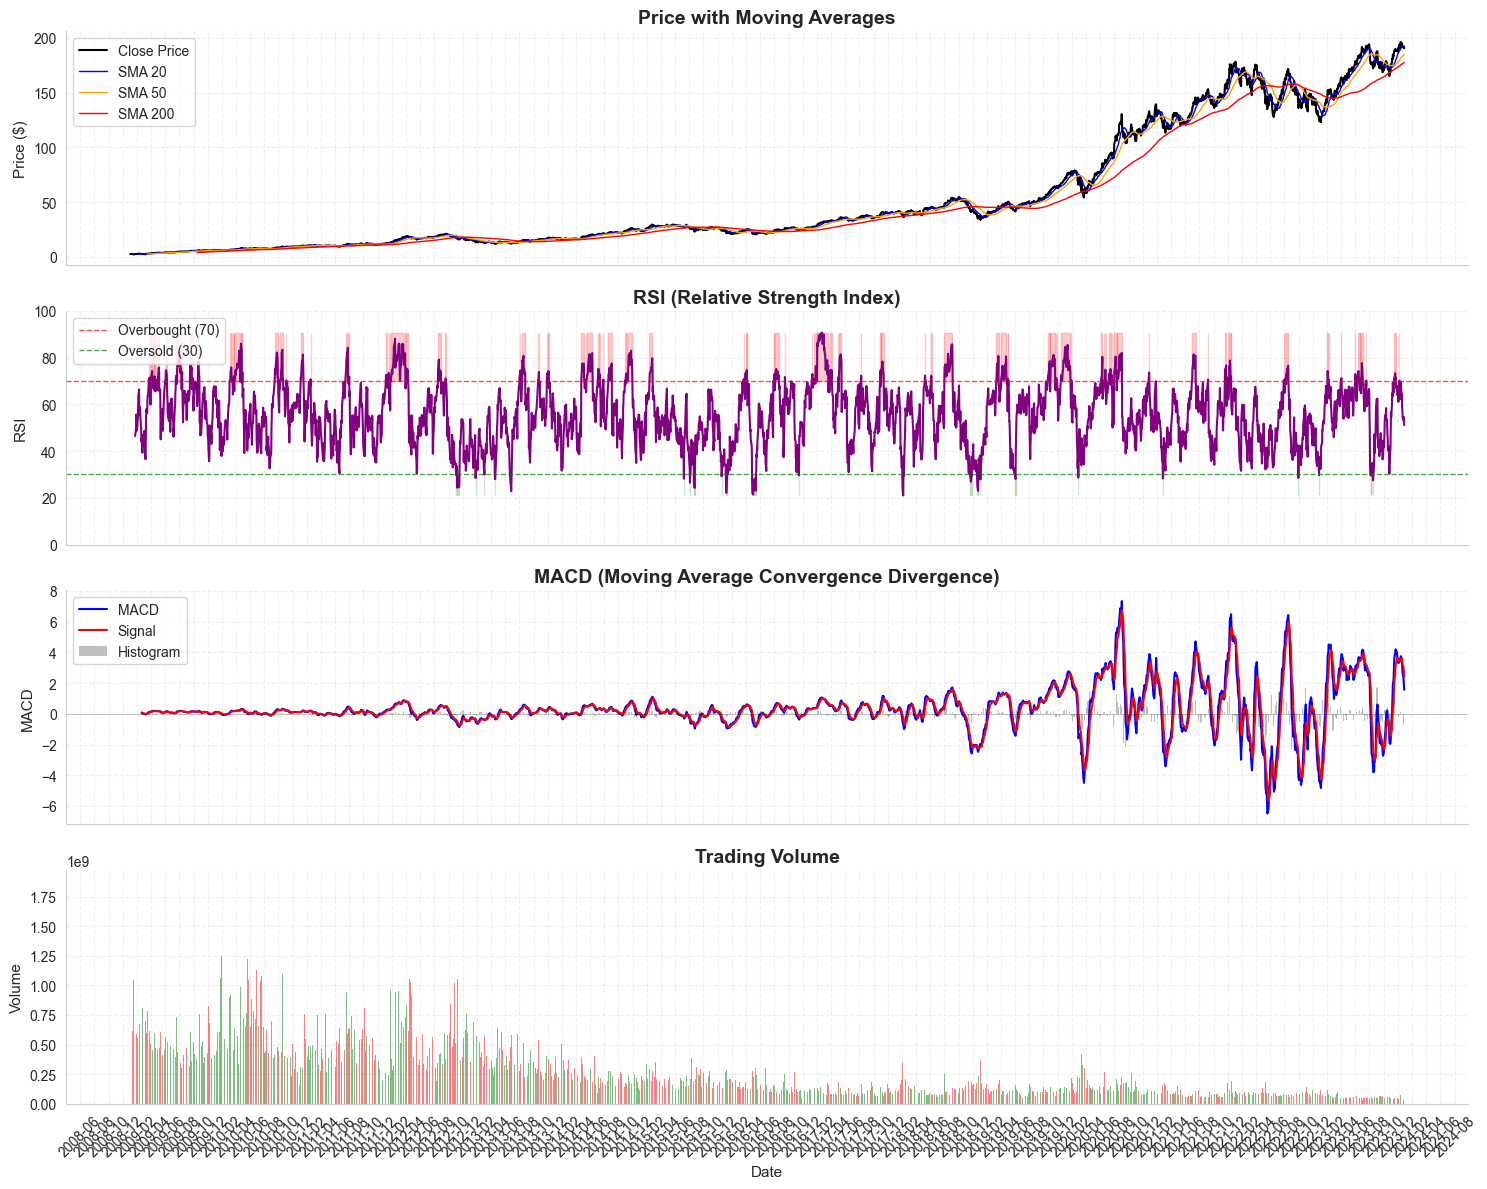

In [13]:
# Set seaborn style for cleaner look
sns.set_style("whitegrid")
sns.set_palette("husl")

# Remove the black border/spines
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True

# Create figure with subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Plot 1: Price with Moving Averages
ax1 = axes[0]
ax1.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=1.5)
ax1.plot(df['Date'], df['SMA_20'], label='SMA 20', color='blue', linewidth=1)
ax1.plot(df['Date'], df['SMA_50'], label='SMA 50', color='orange', linewidth=1)
if 'SMA_200' in df.columns:
    ax1.plot(df['Date'], df['SMA_200'], label='SMA 200', color='red', linewidth=1)
ax1.set_ylabel('Price ($)', fontsize=11)
ax1.set_title('Price with Moving Averages', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=False)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', labelbottom=False)

# Plot 2: RSI
ax2 = axes[1]
ax2.plot(df['Date'], df['RSI'], color='purple', linewidth=1.5)
ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, linewidth=1, label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, linewidth=1, label='Oversold (30)')
ax2.fill_between(df['Date'], 70, df['RSI'].max(), where=(df['RSI'] >= 70), color='red', alpha=0.2)
ax2.fill_between(df['Date'], df['RSI'].min(), 30, where=(df['RSI'] <= 30), color='green', alpha=0.2)
ax2.set_ylabel('RSI', fontsize=11)
ax2.set_title('RSI (Relative Strength Index)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left', frameon=True, fancybox=True, shadow=False)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', labelbottom=False)

# Plot 3: MACD
ax3 = axes[2]
ax3.plot(df['Date'], df['MACD'], label='MACD', color='blue', linewidth=1.5)
ax3.plot(df['Date'], df['MACD_signal'], label='Signal', color='red', linewidth=1.5)
# Use bar with no edge color to avoid zigzag
ax3.bar(df['Date'], df['MACD_histogram'], label='Histogram', 
        color='gray', alpha=0.5, width=0.8, edgecolor='none')
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5)
ax3.set_ylabel('MACD', fontsize=11)
ax3.set_title('MACD (Moving Average Convergence Divergence)', fontsize=14, fontweight='bold')
ax3.legend(loc='upper left', frameon=True, fancybox=True, shadow=False)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.tick_params(axis='x', labelbottom=False)

# Plot 4: Volume
ax4 = axes[3]
colors = ['green' if df['Close'].iloc[i] >= df['Close'].iloc[i-1] else 'red' 
          for i in range(len(df))]
colors[0] = 'gray'  # First day color

ax4.bar(df['Date'], df['Volume'], color=colors, alpha=0.5, width=0.8, edgecolor='none')
ax4.set_ylabel('Volume', fontsize=11)
ax4.set_title('Trading Volume', fontsize=14, fontweight='bold')
ax4.set_xlabel('Date', fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--')

# Format x-axis dates
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

## PyNance for Financial Metrics

### DAILY RETURNS

In [14]:
# Calculate daily percentage returns using Close price
df['Daily_Return'] = df['Close'].pct_change()

print("✅ Daily returns calculated")

# Display sample returns
print("\n📊 Daily Returns Sample:")
print(df[['Date', 'Close', 'Daily_Return']].head())

✅ Daily returns calculated

📊 Daily Returns Sample:
        Date     Close  Daily_Return
0 2009-01-02  2.721686           NaN
1 2009-01-05  2.836553      0.042204
2 2009-01-06  2.789767     -0.016494
3 2009-01-07  2.729484     -0.021609
4 2009-01-08  2.780169      0.018570


### CUMULATIVE RETURNS

In [15]:
# Calculate cumulative returns
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1

print("✅ Cumulative returns calculated")

# Current cumulative return
current_cum_return = df['Cumulative_Return'].iloc[-1]

print(f"\n📊 Total Cumulative Return: {current_cum_return*100:.2f}%")

✅ Cumulative returns calculated

📊 Total Cumulative Return: 6907.74%


### VOLATILITY (RISK)

In [16]:
# Annualized volatility
daily_volatility = df['Daily_Return'].std()

annualized_volatility = daily_volatility * np.sqrt(252)

print("\n📊 Volatility Metrics:")
print(f"   Daily Volatility: {daily_volatility:.4f}")
print(f"   Annualized Volatility: {annualized_volatility:.4f}")
print(f"   Annualized Volatility (%): {annualized_volatility*100:.2f}%")


📊 Volatility Metrics:
   Daily Volatility: 0.0180
   Annualized Volatility: 0.2859
   Annualized Volatility (%): 28.59%


### SHARPE RATIO

In [17]:
# Assume 2% annual risk-free rate
risk_free_rate = 0.02

# Annualized average return
annual_return = df['Daily_Return'].mean() * 252

# Sharpe Ratio
sharpe_ratio = (annual_return - risk_free_rate) / annualized_volatility

print("\n📊 Sharpe Ratio:")
print(f"   Annual Return: {annual_return*100:.2f}%")
print(f"   Sharpe Ratio: {sharpe_ratio:.4f}")

# Interpretation
if sharpe_ratio > 1:
    print("   ✅ Good risk-adjusted returns")
elif sharpe_ratio > 0:
    print("   ➡️ Moderate risk-adjusted returns")
else:
    print("   ⚠️ Poor risk-adjusted returns")


📊 Sharpe Ratio:
   Annual Return: 32.49%
   Sharpe Ratio: 1.0663
   ✅ Good risk-adjusted returns


### MAXIMUM DRAWDOWN

In [18]:
# Rolling maximum close price
df['Rolling_Max'] = df['Close'].cummax()

# Drawdown calculation
df['Drawdown'] = (
    (df['Close'] - df['Rolling_Max'])
    / df['Rolling_Max']
)

# Maximum drawdown
max_drawdown = df['Drawdown'].min()

print("\n📊 Maximum Drawdown:")
print(f"   Max Drawdown: {max_drawdown*100:.2f}%")


📊 Maximum Drawdown:
   Max Drawdown: -43.80%


### ROLLING VOLATILITY

In [19]:
# 30-day rolling volatility
df['Rolling_Volatility_30'] = (
    df['Daily_Return']
    .rolling(window=30)
    .std()
    * np.sqrt(252)
)

print("\n✅ 30-day rolling volatility calculated")


✅ 30-day rolling volatility calculated


### FINANCIAL METRICS SUMMARY TABLE

In [20]:
print("\nFINANCIAL METRICS SUMMARY")

financial_metrics = {
    'Metric': [
        'Cumulative Return',
        'Annualized Volatility',
        'Sharpe Ratio',
        'Maximum Drawdown'
    ],
    'Value': [
        f"{current_cum_return*100:.2f}%",
        f"{annualized_volatility*100:.2f}%",
        f"{sharpe_ratio:.4f}",
        f"{max_drawdown*100:.2f}%"
    ]
}

financial_df = pd.DataFrame(financial_metrics)

print("\n", financial_df.to_string(index=False))


FINANCIAL METRICS SUMMARY

                Metric    Value
    Cumulative Return 6907.74%
Annualized Volatility   28.59%
         Sharpe Ratio   1.0663
     Maximum Drawdown  -43.80%


### VISUALIZATION

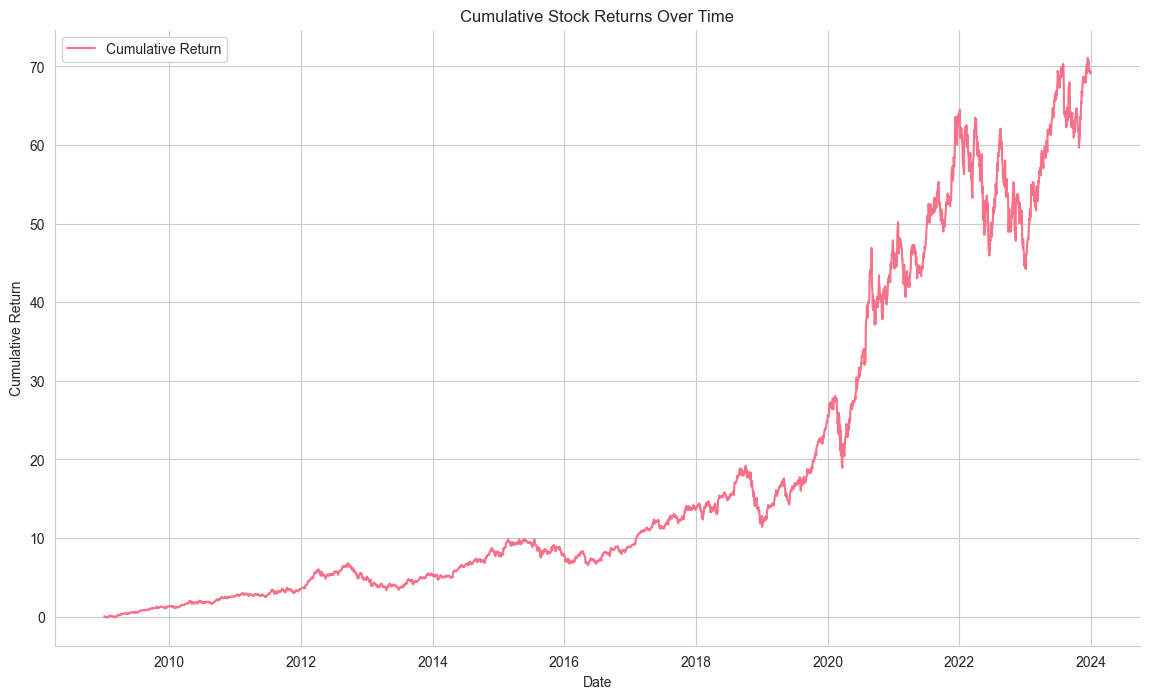

In [21]:
# Create figure
plt.figure(figsize=(14, 8))

# Plot cumulative return
plt.plot(df['Date'], df['Cumulative_Return'],
         label='Cumulative Return')

plt.title('Cumulative Stock Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)

plt.show()

## CREATE VISUALIZATION

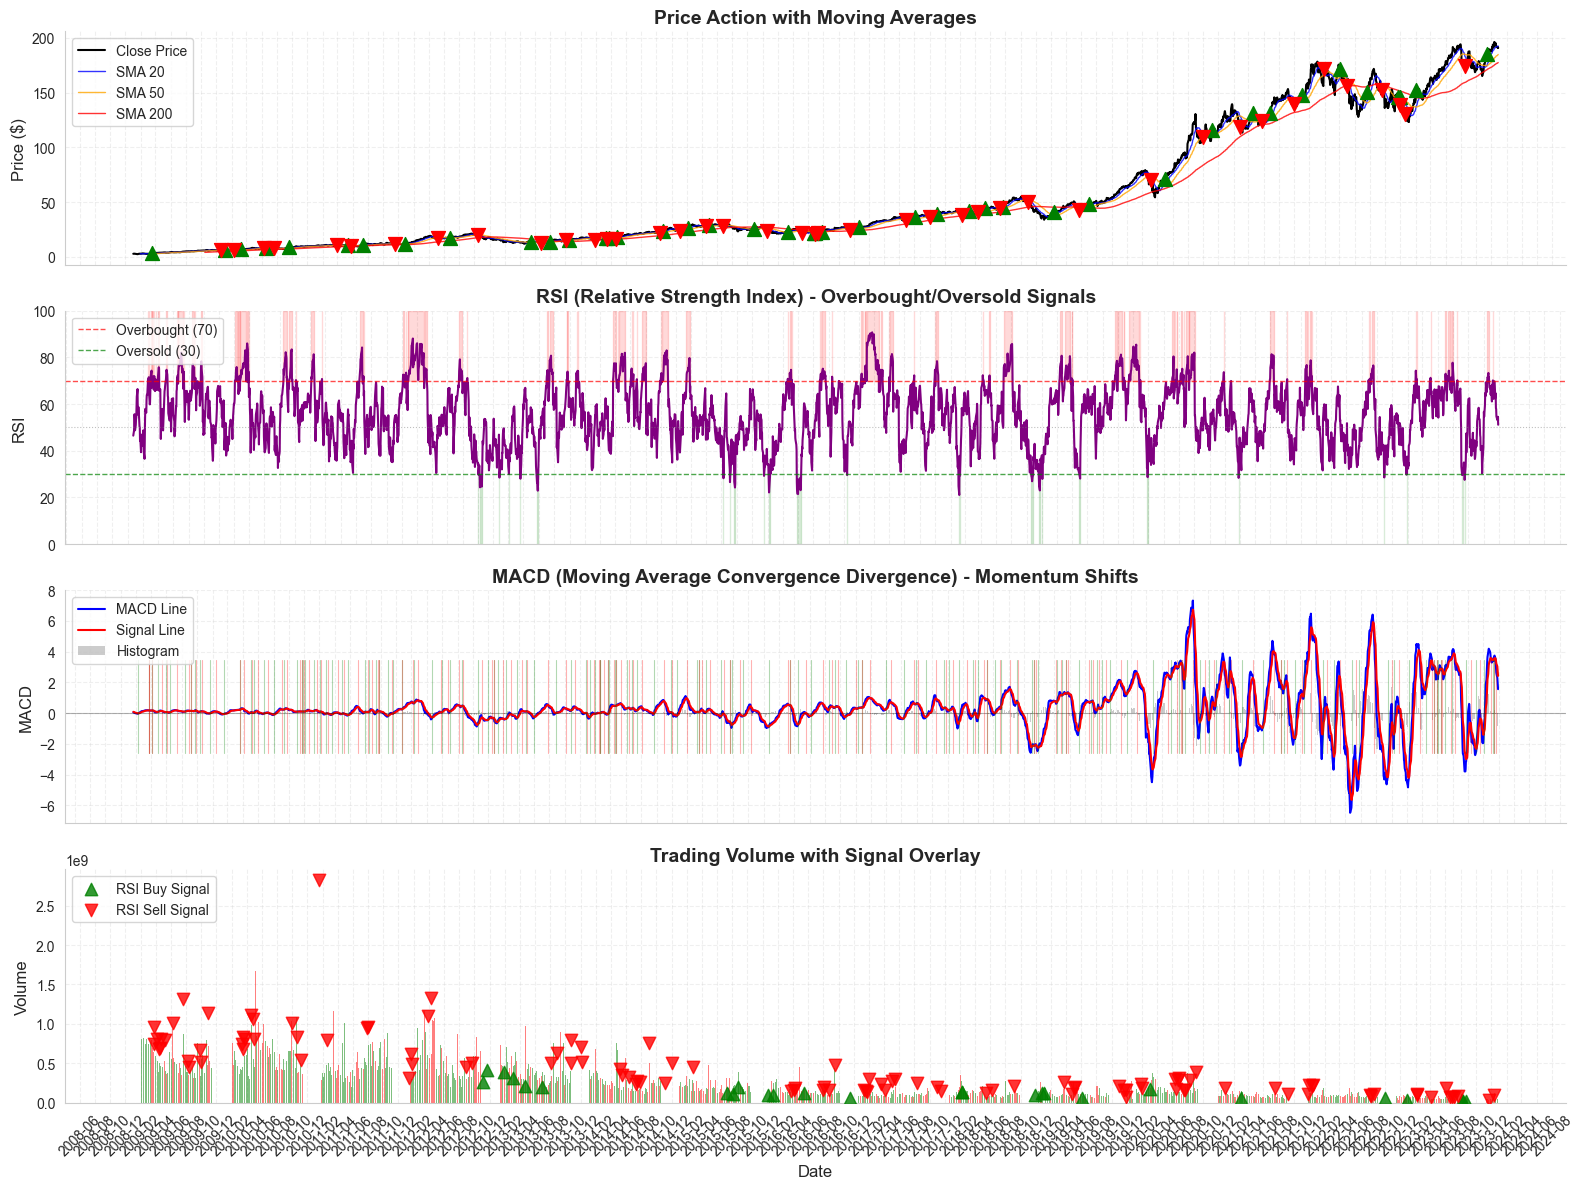

In [ ]:
fig = plt.figure(figsize=(16, 12))

# Panel 1: Price with Moving Averages (4 rows height)
ax1 = plt.subplot(4, 1, 1)
ax1.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=1.5)
ax1.plot(df['Date'], df['SMA_20'], label='SMA 20', color='blue', linewidth=1, alpha=0.8)
ax1.plot(df['Date'], df['SMA_50'], label='SMA 50', color='orange', linewidth=1, alpha=0.8)

if 'SMA_200' in df.columns:
    ax1.plot(df['Date'], df['SMA_200'], label='SMA 200', color='red', linewidth=1, alpha=0.8)

ax1.set_ylabel('Price ($)', fontsize=12)
ax1.set_title('Price Action with Moving Averages', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', labelbottom=False)

# Highlight crossover points (Golden Cross / Death Cross)
# Golden Cross: SMA_20 crosses above SMA_50
if len(df) > 1:
    golden_cross = (df['SMA_20'] > df['SMA_50']) & (df['SMA_20'].shift(1) <= df['SMA_50'].shift(1))
    death_cross = (df['SMA_20'] < df['SMA_50']) & (df['SMA_20'].shift(1) >= df['SMA_50'].shift(1))
    
    ax1.scatter(df['Date'][golden_cross], df['Close'][golden_cross], 
                color='green', marker='^', s=100, zorder=5, label='Golden Cross (Bullish)')
    ax1.scatter(df['Date'][death_cross], df['Close'][death_cross], 
                color='red', marker='v', s=100, zorder=5, label='Death Cross (Bearish)')

# Panel 2: RSI (4 rows height)
ax2 = plt.subplot(4, 1, 2)
ax2.plot(df['Date'], df['RSI'], color='purple', linewidth=1.5)
ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, linewidth=1, label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, linewidth=1, label='Oversold (30)')
ax2.axhline(y=50, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)

# Shade overbought/oversold regions
ax2.fill_between(df['Date'], 70, 100, where=(df['RSI'] >= 70), color='red', alpha=0.15)
ax2.fill_between(df['Date'], 0, 30, where=(df['RSI'] <= 30), color='green', alpha=0.15)

ax2.set_ylabel('RSI', fontsize=12)
ax2.set_title('RSI (Relative Strength Index) - Overbought/Oversold Signals', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left', frameon=True)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', labelbottom=False)

# Mark potential buy/sell signals based on RSI
# Buy when RSI crosses above 30 (exiting oversold)
rsi_buy_signal = (df['RSI'] > 30) & (df['RSI'].shift(1) <= 30)
rsi_sell_signal = (df['RSI'] < 70) & (df['RSI'].shift(1) >= 70)

# Panel 3: MACD (4 rows height)
ax3 = plt.subplot(4, 1, 3)
ax3.plot(df['Date'], df['MACD'], label='MACD Line', color='blue', linewidth=1.5)
ax3.plot(df['Date'], df['MACD_signal'], label='Signal Line', color='red', linewidth=1.5)
ax3.bar(df['Date'], df['MACD_histogram'], label='Histogram', 
        color='gray', alpha=0.4, width=0.8, edgecolor='none')
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.8)

# Highlight MACD crossovers
macd_bullish = (df['MACD'] > df['MACD_signal']) & (df['MACD'].shift(1) <= df['MACD_signal'].shift(1))
macd_bearish = (df['MACD'] < df['MACD_signal']) & (df['MACD'].shift(1) >= df['MACD_signal'].shift(1))

# Mark crossovers on the plot
for idx in macd_bullish[macd_bullish].index:
    ax3.axvline(x=df['Date'].iloc[idx], color='green', alpha=0.3, linewidth=0.8, ymin=0.3, ymax=0.7)
for idx in macd_bearish[macd_bearish].index:
    ax3.axvline(x=df['Date'].iloc[idx], color='red', alpha=0.3, linewidth=0.8, ymin=0.3, ymax=0.7)

ax3.set_ylabel('MACD', fontsize=12)
ax3.set_title('MACD (Moving Average Convergence Divergence) - Momentum Shifts', fontsize=14, fontweight='bold')
ax3.legend(loc='upper left', frameon=True)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.tick_params(axis='x', labelbottom=False)

# Panel 4: Volume with Buy/Sell Signals (4 rows height)
ax4 = plt.subplot(4, 1, 4)

# Color volume bars: green for up days, red for down days
colors = ['green' if df['Close'].iloc[i] >= df['Close'].iloc[i-1] else 'red' 
          for i in range(len(df))]
colors[0] = 'gray'

ax4.bar(df['Date'], df['Volume'], color=colors, alpha=0.5, width=0.8, edgecolor='none')

# Overlay volume with RSI buy/sell signals from earlier
ax4.scatter(df['Date'][rsi_buy_signal], df['Volume'][rsi_buy_signal] * 0.5,
            color='green', marker='^', s=80, zorder=5, label='RSI Buy Signal', alpha=0.8)
ax4.scatter(df['Date'][rsi_sell_signal], df['Volume'][rsi_sell_signal] * 1.5,
            color='red', marker='v', s=80, zorder=5, label='RSI Sell Signal', alpha=0.8)

ax4.set_ylabel('Volume', fontsize=12)
ax4.set_xlabel('Date', fontsize=12)
ax4.set_title('Trading Volume with Signal Overlay', fontsize=14, fontweight='bold')
ax4.legend(loc='upper left', frameon=True)
ax4.grid(True, alpha=0.3, linestyle='--')

# Format x-axis dates
for ax in [ax1, ax2, ax3, ax4]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### RELATIONSHIP VISUALIZATION: How Indicators Relate to Price Action

C:\Users\hp\AppData\Local\Temp\ipykernel_19280\2198987338.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([box_data, box_data_bear], labels=['Bullish Signals', 'Bearish Signals'], patch_artist=True)


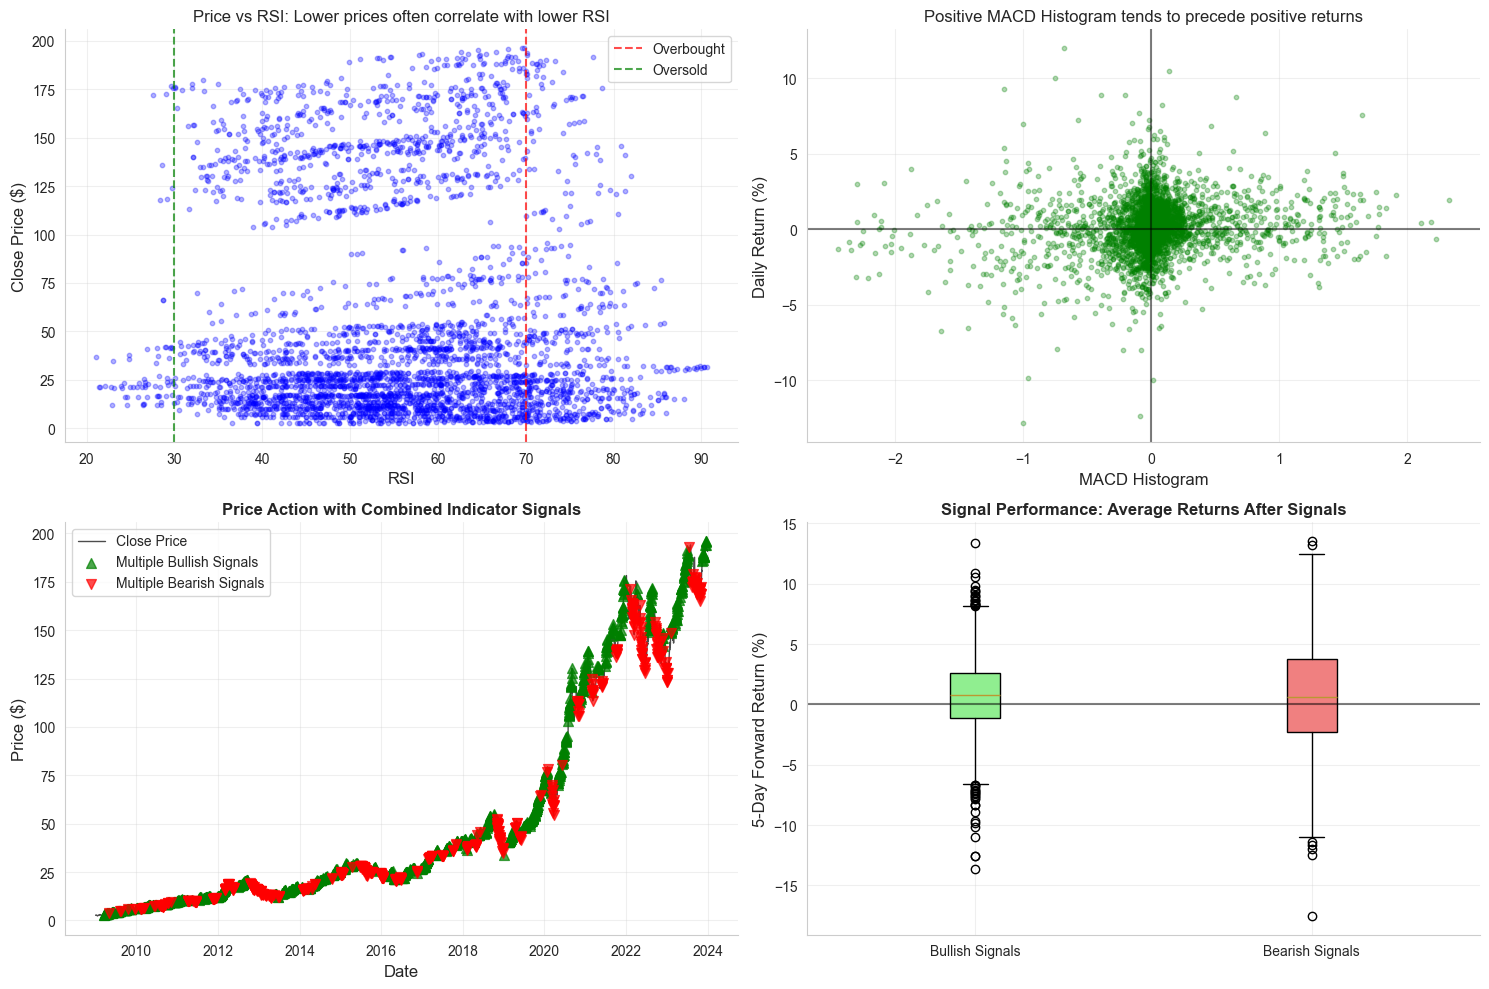

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 3a. RSI vs Price (scatter)
ax = axes[0, 0]
ax.scatter(df['RSI'], df['Close'], alpha=0.3, s=10, c='blue')
ax.axvline(x=70, color='red', linestyle='--', alpha=0.7, label='Overbought')
ax.axvline(x=30, color='green', linestyle='--', alpha=0.7, label='Oversold')
ax.set_xlabel('RSI', fontsize=12)
ax.set_ylabel('Close Price ($)', fontsize=12)
ax.set_title('Price vs RSI: Lower prices often correlate with lower RSI', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 3b. MACD Histogram vs Price Returns
ax = axes[0, 1]
ax.scatter(df['MACD_histogram'], df['Daily_Return'] * 100, alpha=0.3, s=10, c='green')
ax.axvline(x=0, color='black', linestyle='-', alpha=0.5)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('MACD Histogram', fontsize=12)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.set_title('Positive MACD Histogram tends to precede positive returns', fontsize=12)
ax.grid(True, alpha=0.3)

# 3c. Price with indicator signals highlighted
ax = axes[1, 0]
ax.plot(df['Date'], df['Close'], color='black', linewidth=1, alpha=0.7, label='Close Price')

# Highlight days with multiple bullish signals
bullish_signals = pd.Series(0, index=df.index)
bearish_signals = pd.Series(0, index=df.index)

# Combine signals (simplified scoring)
if 'RSI' in df.columns:
    bullish_signals += (df['RSI'] < 30).astype(int)
    bearish_signals += (df['RSI'] > 70).astype(int)

if 'MACD' in df.columns and 'MACD_signal' in df.columns:
    bullish_signals += (df['MACD'] > df['MACD_signal']).astype(int)
    bearish_signals += (df['MACD'] < df['MACD_signal']).astype(int)

if 'SMA_20' in df.columns and 'SMA_50' in df.columns:
    bullish_signals += (df['SMA_20'] > df['SMA_50']).astype(int)
    bearish_signals += (df['SMA_20'] < df['SMA_50']).astype(int)

# Mark high-signal days
strong_bullish = bullish_signals >= 2
strong_bearish = bearish_signals >= 2

ax.scatter(df['Date'][strong_bullish], df['Close'][strong_bullish], 
           color='green', marker='^', s=50, alpha=0.7, label='Multiple Bullish Signals', zorder=5)
ax.scatter(df['Date'][strong_bearish], df['Close'][strong_bearish], 
           color='red', marker='v', s=50, alpha=0.7, label='Multiple Bearish Signals', zorder=5)

ax.set_ylabel('Price ($)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title('Price Action with Combined Indicator Signals', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)

# 3d. Signal Performance (Returns after signals)
ax = axes[1, 1]

# Calculate forward returns after signals
forward_returns = []
signal_types = []

for i in strong_bullish[strong_bullish].index:
    if i + 5 < len(df):
        forward_returns.append(df['Close'].iloc[i+5] / df['Close'].iloc[i] - 1)
        signal_types.append('Bullish')

for i in strong_bearish[strong_bearish].index:
    if i + 5 < len(df):
        forward_returns.append(df['Close'].iloc[i+5] / df['Close'].iloc[i] - 1)
        signal_types.append('Bearish')

if len(forward_returns) > 0:
    box_data = [forward_returns[i] * 100 for i in range(len(forward_returns)) if signal_types[i] == 'Bullish']
    box_data_bear = [forward_returns[i] * 100 for i in range(len(forward_returns)) if signal_types[i] == 'Bearish']
    
    bp = ax.boxplot([box_data, box_data_bear], labels=['Bullish Signals', 'Bearish Signals'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax.set_ylabel('5-Day Forward Return (%)', fontsize=12)
    ax.set_title('Signal Performance: Average Returns After Signals', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### SUMMARY OF FINDINGS

In [26]:
print(f"""
📊 Moving Averages:
   - Golden Cross (Bullish) signals: {golden_cross.sum()}
   - Death Cross (Bearish) signals: {death_cross.sum()}

📊 RSI Signals:
   - Oversold (RSI < 30) buy signals: {rsi_buy_signal.sum()}
   - Overbought (RSI > 70) sell signals: {rsi_sell_signal.sum()}

📊 MACD Crossovers:
   - Bullish crossovers: {macd_bullish.sum()}
   - Bearish crossovers: {macd_bearish.sum()}

📊 Combined Signal Performance:
   - Days with 2+ bullish signals: {strong_bullish.sum()}
   - Days with 2+ bearish signals: {strong_bearish.sum()}
""")

# Calculate average returns after signals
if len(forward_returns) > 0:
    bullish_avg_return = np.mean([r for r, t in zip(forward_returns, signal_types) if t == 'Bullish']) * 100
    bearish_avg_return = np.mean([r for r, t in zip(forward_returns, signal_types) if t == 'Bearish']) * 100
    print(f"   Avg 5-day return after bullish signals: {bullish_avg_return:.2f}%")
    print(f"   Avg 5-day return after bearish signals: {bearish_avg_return:.2f}%")


📊 Moving Averages:
   - Golden Cross (Bullish) signals: 42
   - Death Cross (Bearish) signals: 41

📊 RSI Signals:
   - Oversold (RSI < 30) buy signals: 26
   - Overbought (RSI > 70) sell signals: 110

📊 MACD Crossovers:
   - Bullish crossovers: 140
   - Bearish crossovers: 140

📊 Combined Signal Performance:
   - Days with 2+ bullish signals: 1178
   - Days with 2+ bearish signals: 571

   Avg 5-day return after bullish signals: 0.71%
   Avg 5-day return after bearish signals: 0.63%
